# IMPORTS

## System

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Remonte de deux niveaux (si ton notebook est dans /notebooks/exploration.ipynb)
# pour atteindre la racine du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from config.config import *

from PIL import Image

## Données

In [3]:
images_cancer_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / "cancer"
images_normal_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / "normal"

# Labels : cancer

In [4]:
metadata_list = []
image:Path

for image in images_cancer_dir.glob('*') :
    img = Image.open(image)

    metadata = {
        'name' : image.name,
        'format' : img.format,
        'width' : img.width,
        'height' : img.height,
        'mode' : img.mode,
        'file_size' : os.path.getsize(image),
    }

    metadata_list.append(metadata)

df_cancer = pd.DataFrame(metadata_list)

## Visualisation

In [5]:
df_cancer.head()

,name,format,width,height,mode,file_size
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,JPEG,512,512,RGB,25845
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,JPEG,512,512,RGB,18082
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,JPEG,512,512,RGB,18113
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,JPEG,512,512,RGB,24615
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,JPEG,512,512,RGB,24723


In [6]:
df_cancer.describe(include='all')

,name,format,width,height,mode,file_size
count,50,50,50.0,50.0,50,50.000000
unique,50,1,NaN,NaN,1,NaN
top,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,JPEG,NaN,NaN,RGB,NaN
freq,1,50,NaN,NaN,50,NaN
mean,NaN,NaN,512.0,512.0,NaN,23036.520000
std,NaN,NaN,0.0,0.0,NaN,4074.946246
min,NaN,NaN,512.0,512.0,NaN,16207.000000
25%,NaN,NaN,512.0,512.0,NaN,19788.000000
50%,NaN,NaN,512.0,512.0,NaN,23534.500000
75%,NaN,NaN,512.0,512.0,NaN,25819.000000


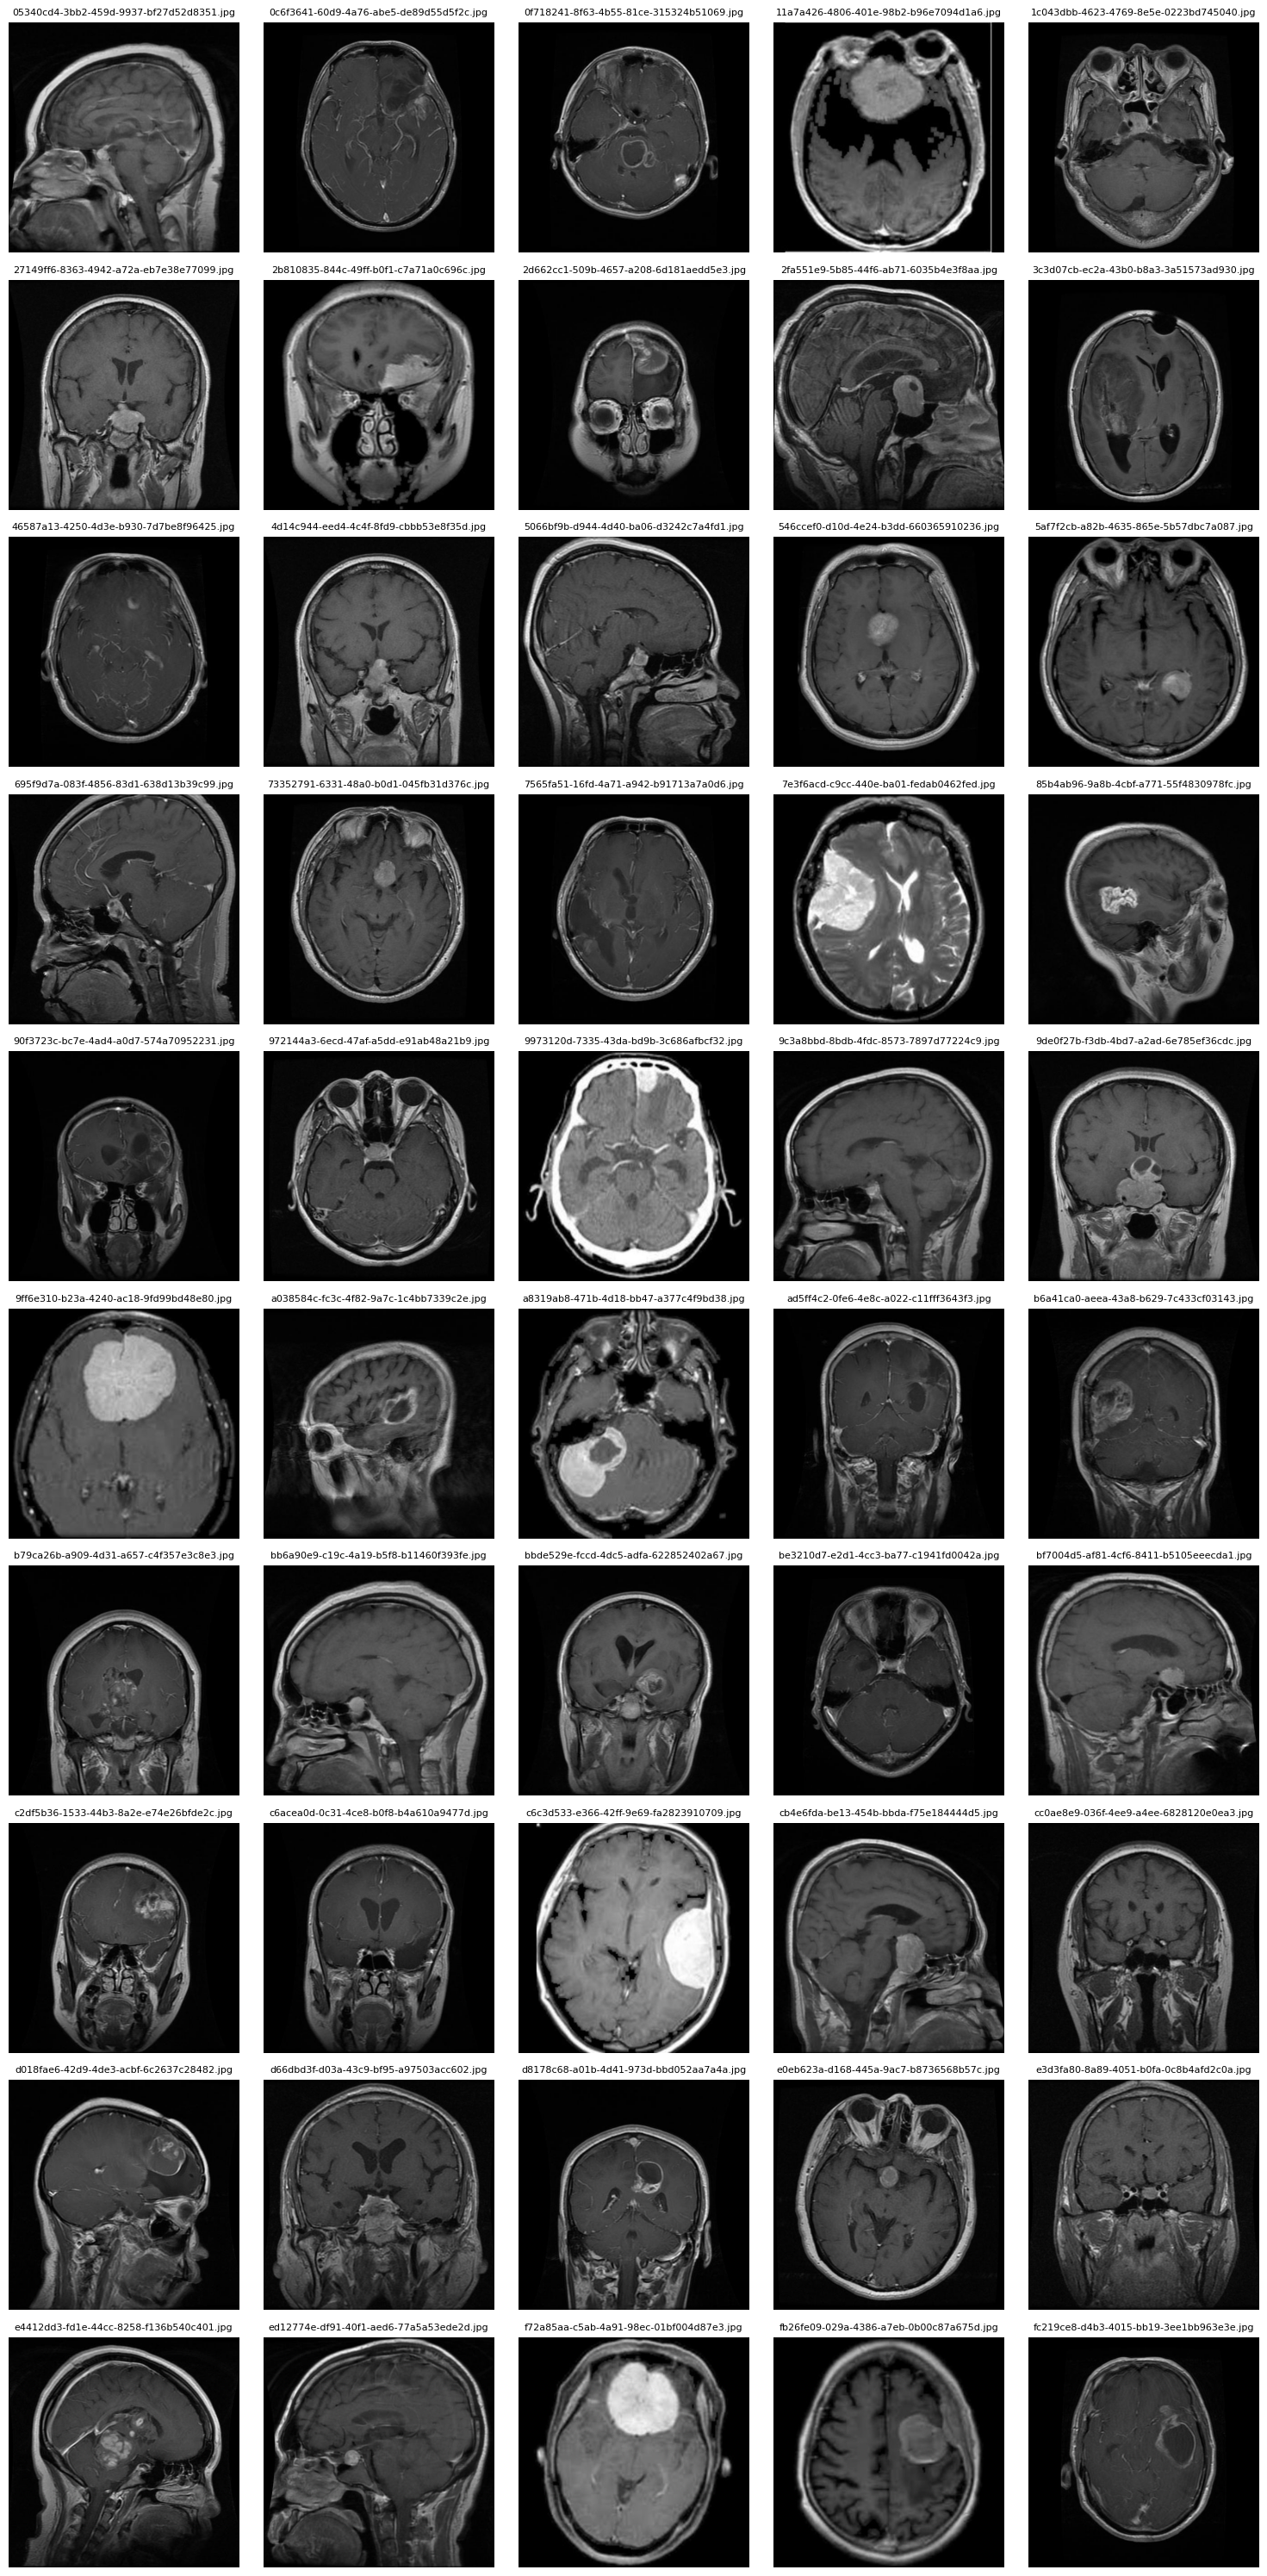

In [7]:
# Récupérer les 10 premières images
images = list(images_cancer_dir.glob('*'))

# Créer une grille 2x5
fig, axes = plt.subplots(10, 5, figsize=(15, 30))
axes = axes.flatten()

for idx, img_path in enumerate(images):
    img = Image.open(img_path)
    axes[idx].imshow(img)  # Sans cmap='gray' pour afficher en couleur
    axes[idx].set_title(img_path.name, fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Observations :
- Nous avons 50 images labelisées au format JPEG
- Images carrées de 512px
- Toutes au format jpeg
- Taille : mean = 23 Ko ; min = 16 Ko ; max = 32.5 Ko
- Toutes en RGB
- Les images sont prises sous différentes orientations : Haut, coté, face

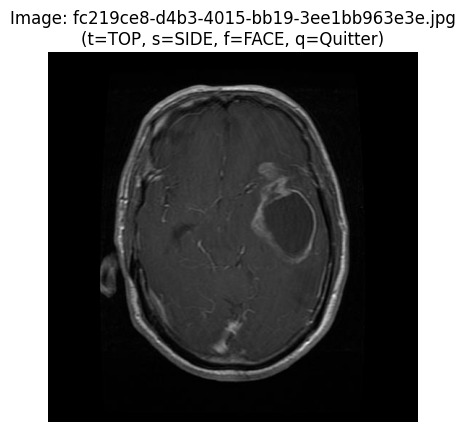


Résumé du classement :
- Axial : 22
- Sagittal : 13
- Coronal : 15


In [8]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from PIL import Image

# Listes pour stocker les noms de fichiers
TOP_list = []
SIDE_list = []
FACE_list = []

# On récupère toutes les images à classer (par exemple celles du dossier cancer)
images_to_label = sorted(list(images_cancer_dir.glob('*.jpg')))

print(f"Début du classement de {len(images_to_label)} images...")

for img_path in images_to_label:
    clear_output(wait=True)
    
    # Affichage de l'image
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Image: {img_path.name}\n(t=TOP, s=SIDE, f=FACE, q=Quitter)")
    plt.axis('off')
    plt.show()
    
    # Demande d'input à l'utilisateur
    choice = input("Angle (t/s/f/q) ? ").lower()
    
    if choice == 't':
        TOP_list.append(img_path.name)
    elif choice == 's':
        SIDE_list.append(img_path.name)
    elif choice == 'f':
        FACE_list.append(img_path.name)
    elif choice == 'q':
        print("Fin prématurée du classement.")
        break
    else:
        print("Choix invalide, image ignorée.")

print(f"\nRésumé du classement :")
print(f"- Axial : {len(TOP_list)}")
print(f"- Sagittal : {len(SIDE_list)}")
print(f"- Coronal : {len(FACE_list)}")

# Facultatif : création d'un petit DataFrame de correspondance
# df_orientations = pd.DataFrame(
#     [(name, 'Axial') for name in axial_list] + 
#     [(name, 'Sagittal') for name in sagittal_list] + 
#     [(name, 'Coronal') for name in coronal_list],
#     columns=['name', 'orientation']
# )

In [9]:
df_cancer.loc[df_cancer['name'].isin(TOP_list),'orientation'] = 'top'

In [10]:
df_cancer.loc[df_cancer['name'].isin(SIDE_list),'orientation'] = 'side'

In [11]:
df_cancer.loc[df_cancer['name'].isin(FACE_list),'orientation'] = 'face'

In [12]:
df_cancer.head(15)

,name,format,width,height,mode,file_size,orientation
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,JPEG,512,512,RGB,25845,side
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,JPEG,512,512,RGB,18082,top
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,JPEG,512,512,RGB,18113,top
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,JPEG,512,512,RGB,24615,top
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,JPEG,512,512,RGB,24723,top
5,27149ff6-8363-4942-a72a-eb7e38e77099.jpg,JPEG,512,512,RGB,29152,face
6,2b810835-844c-49ff-b0f1-c7a71a0c696c.jpg,JPEG,512,512,RGB,22917,face
7,2d662cc1-509b-4657-a208-6d181aedd5e3.jpg,JPEG,512,512,RGB,17090,face
8,2fa551e9-5b85-44f6-ab71-6035b4e3f8aa.jpg,JPEG,512,512,RGB,32586,side
9,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,JPEG,512,512,RGB,19275,top


In [13]:
df_cancer.to_csv(BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / 'summary_cancer_images.csv')

# Labels : normal

In [14]:
metadata_list = []
image:Path

for image in images_normal_dir.glob('*') :
    img = Image.open(image)

    metadata = {
        'name' : image.name,
        'format' : img.format,
        'width' : img.width,
        'height' : img.height,
        'mode' : img.mode,
        'file_size' : os.path.getsize(image),
    }

    metadata_list.append(metadata)

df_normal = pd.DataFrame(metadata_list)

## Visualisation

In [15]:
df_normal.head()

,name,format,width,height,mode,file_size
0,0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg,JPEG,512,512,RGB,23557
1,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,JPEG,512,512,RGB,26027
2,11825cf3-9b35-42d3-ac99-21f26dd2f94e.jpg,JPEG,512,512,RGB,28994
3,14703976-0467-4acb-ade4-8a375ebfd4f9.jpg,JPEG,512,512,RGB,27527
4,1953e998-29b8-4d36-975f-007c4fcb84a3.jpg,JPEG,512,512,RGB,28816


In [16]:
df_normal.describe(include='all')

,name,format,width,height,mode,file_size
count,50,50,50.0,50.0,50,50.000000
unique,50,1,NaN,NaN,1,NaN
top,0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg,JPEG,NaN,NaN,RGB,NaN
freq,1,50,NaN,NaN,50,NaN
mean,NaN,NaN,512.0,512.0,NaN,29837.400000
std,NaN,NaN,0.0,0.0,NaN,11629.940771
min,NaN,NaN,512.0,512.0,NaN,17771.000000
25%,NaN,NaN,512.0,512.0,NaN,23565.250000
50%,NaN,NaN,512.0,512.0,NaN,25889.500000
75%,NaN,NaN,512.0,512.0,NaN,30069.500000


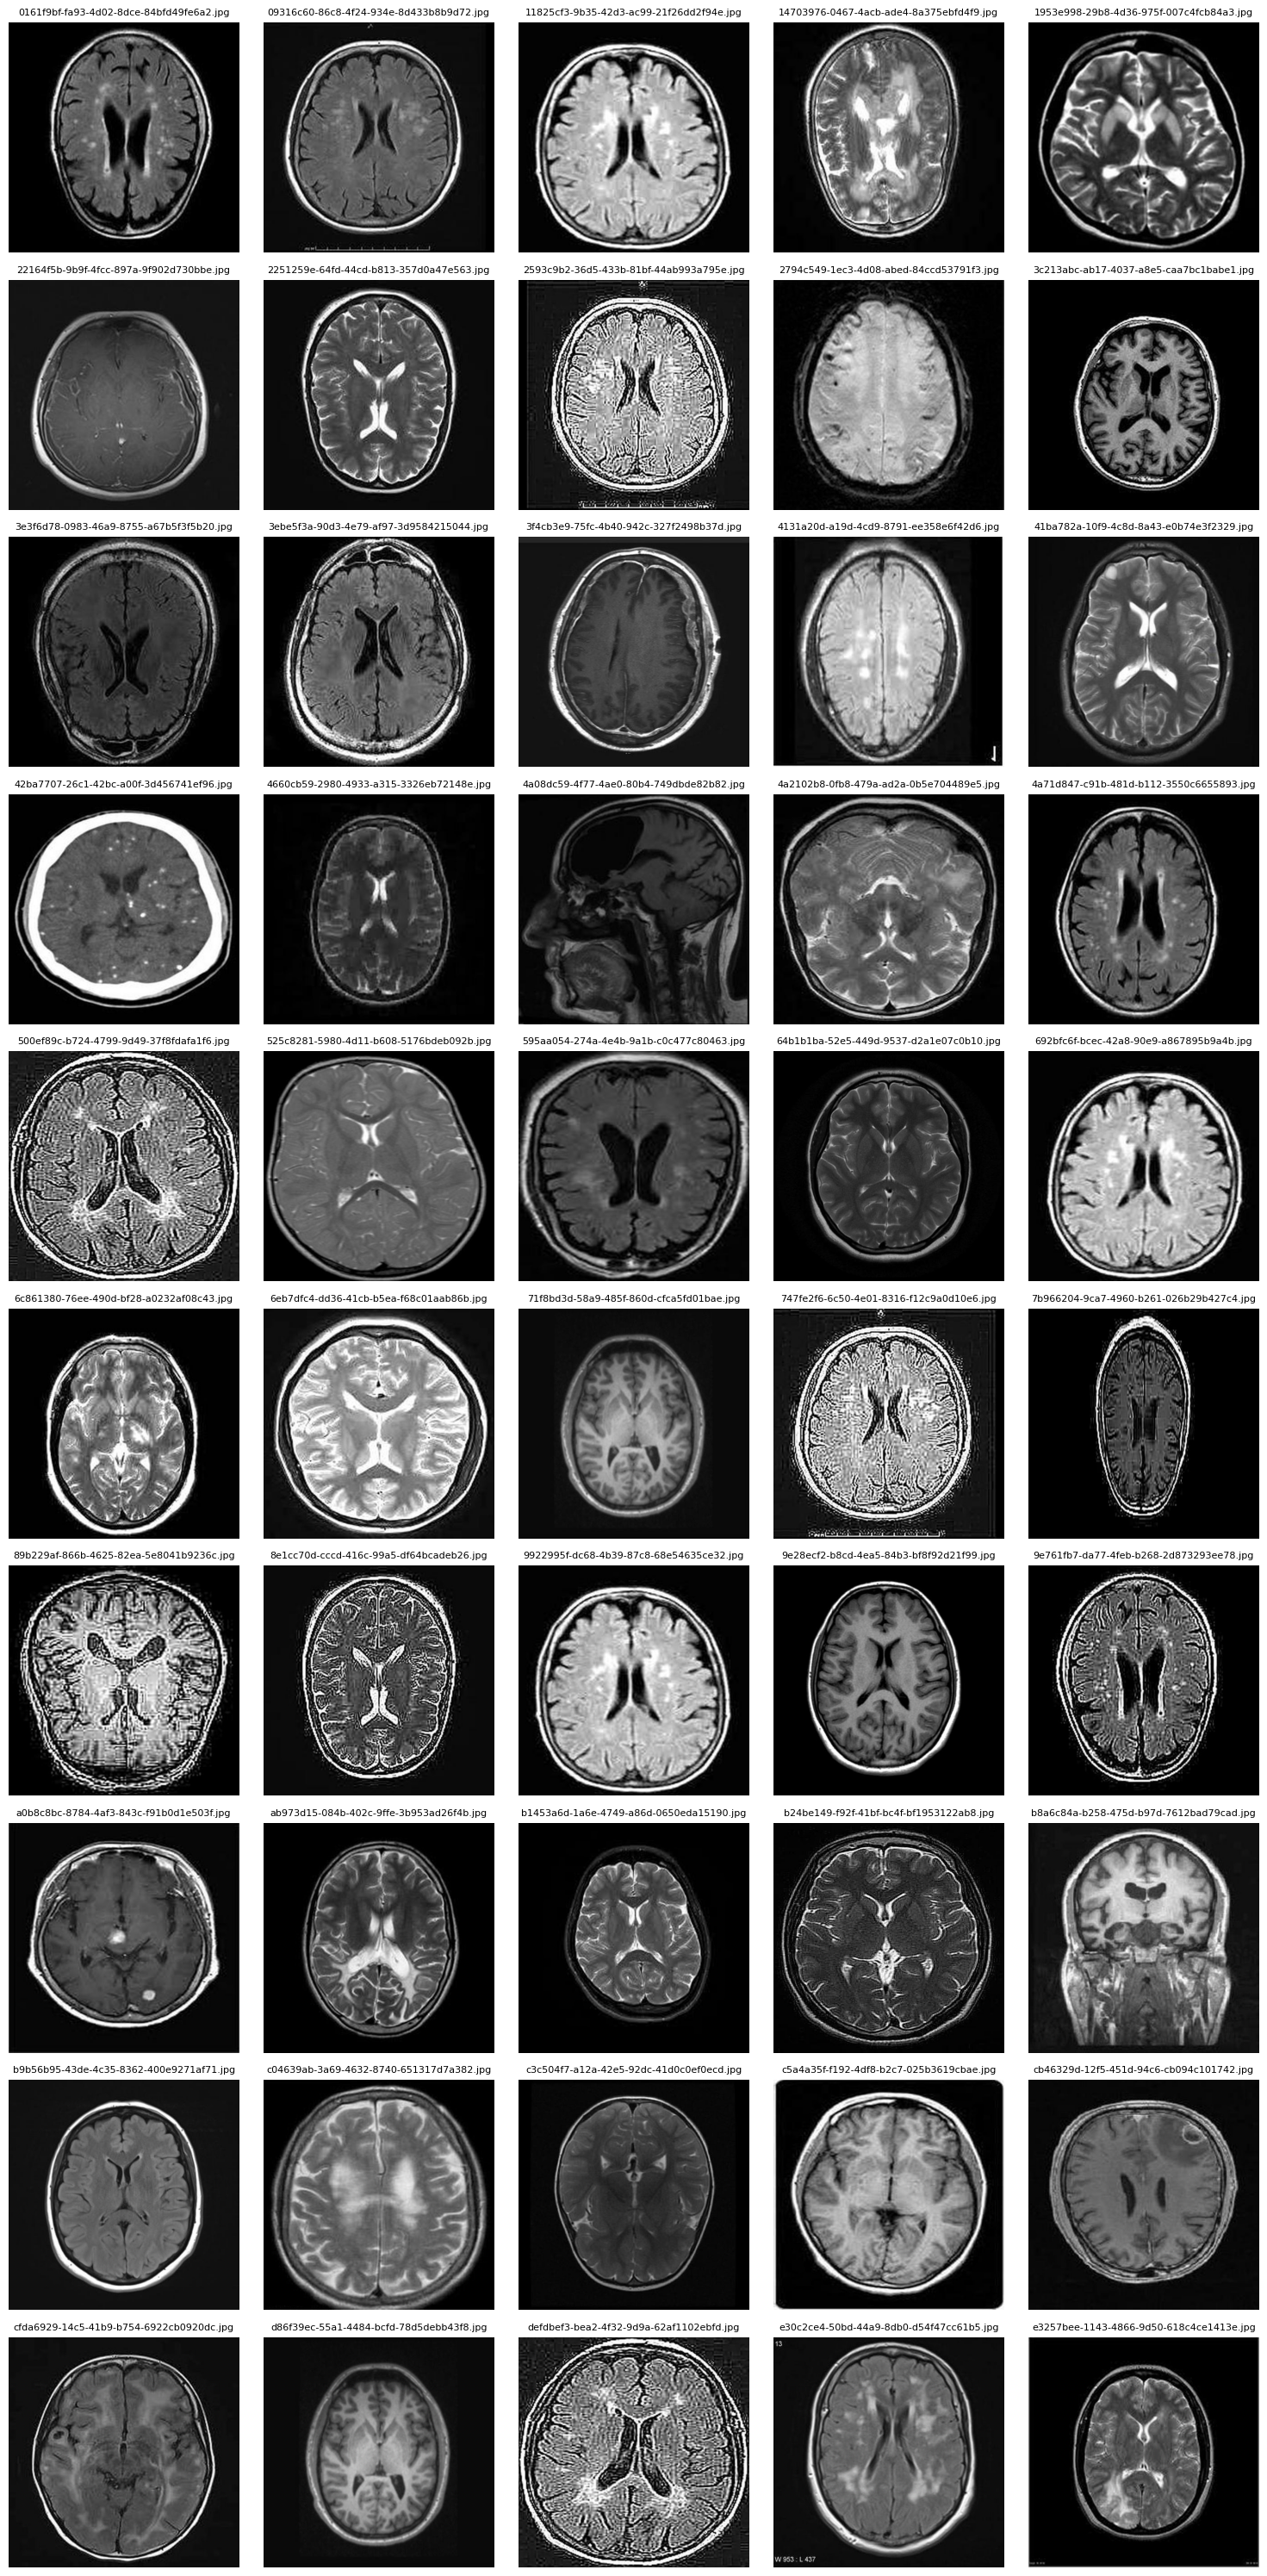

In [17]:
# Récupérer les 10 premières images
images = list(images_normal_dir.glob('*'))

# Créer une grille 2x5
fig, axes = plt.subplots(10, 5, figsize=(15, 30))
axes = axes.flatten()

for idx, img_path in enumerate(images):
    img = Image.open(img_path)
    axes[idx].imshow(img)  # Sans cmap='gray' pour afficher en couleur
    axes[idx].set_title(img_path.name, fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Observations :
- Nous avons 50 images labelisées au format JPEG
- Images carrées de 512px
- Toutes au format jpeg
- Taille : mean = 29.8 Ko ; min = 17 Ko ; max = 65.8 Ko
- Toutes en RGB
- 48 images sur 50 sont prise d'en haut, les 2 restantes sont prises de coté ou de face

In [18]:
df_normal['orientation'] = 'top'

In [19]:
df_normal.loc[df_normal['name'] == '4a08dc59-4f77-4ae0-80b4-749dbde82b82.jpg','orientation'] = 'side'
df_normal.loc[df_normal['name'] == 'b8a6c84a-b258-475d-b97d-7612bad79cad.jpg','orientation'] = 'face'

In [20]:
df_normal.to_csv(BASE_DIR / "mri_dataset_brain_cancer_oc" / "avec_labels" / 'summary_normal_images.csv')